In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(  # since this is a generated data, we get the output(y) but we ignore that value
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

KMeans

In [4]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    random_state=42
)

labels = kmeans.fit_predict(X)    # we need to scale our data

<Axes: >

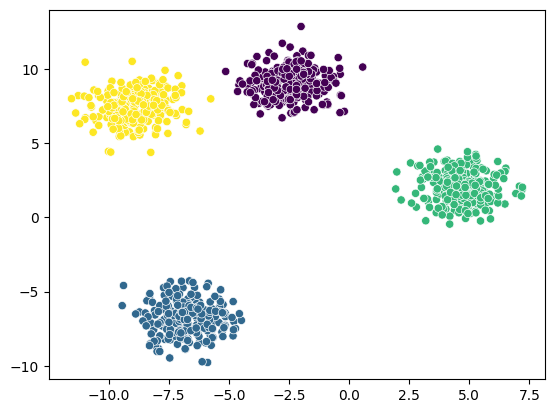

In [6]:
sns.scatterplot(x= X[:, 0], y= X[:, 1], c= labels)

### Choosing the k value

In [ ]:
# Method 1: Elbow method
wcss = []

for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_) # inertia_ attribute contains the wcss or sqaured sum value



<Axes: >

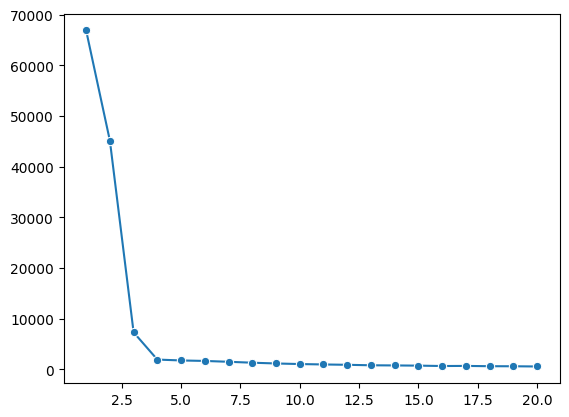

In [15]:
sns.lineplot(x=range(1,21), y=wcss, marker='o')

In [19]:
# To automatically find the k value, we can use the kneed module

# !pip install kneed

from kneed import KneeLocator

knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")
print("Optimal K=", knee.knee)

Optimal K= 4


In [ ]:
# Method 2: Silhuoette score

from sklearn.metrics import silhouette_score

ss = []
for k in range(2, 21):  # 1 throws error
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels) # Higher the ss score, better the k value
    ss.append(score)

<Axes: >

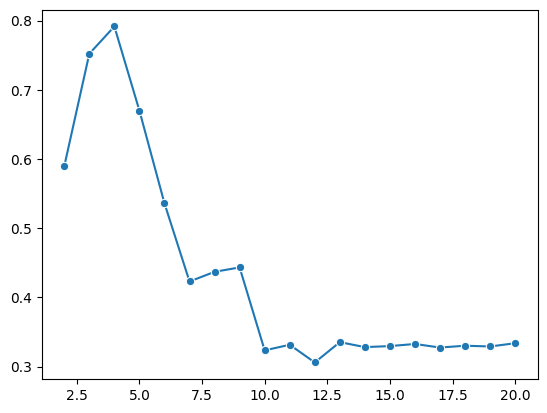

In [21]:
sns.lineplot(x=range(2,21), y=ss, marker="o")